In [31]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project")
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from functions_v2 import *
from two_level_mc import *
from graph_mlmc_model import GraphTwoLevelModel
from mlmc_runner import MLMCRunner
from sksparse.cholmod import cholesky as sparse_cholesky

In [27]:
edges, n_vertices, edge_weights = load_graph(r"../../data/raw/oregon1_010526.txt")
num_components = check_connectivity(edges, n_vertices)
if num_components > 1:
    edges, n_vertices, edge_weights = filter_to_largest_component(edges, n_vertices, edge_weights)

A, D, L = build_graph_matrices(edges, n_vertices)
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)

import networkx as nx
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

✓ Loaded: ../../data/raw/oregon1_010526.txt
  Vertices : 11174
  Edges    : 23409
  Weighted : no

Components: 1
  -> Graph is fully connected, safe to proceed

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 11174 x 11174
  Degree range: [1, 2389]
  Non-zeros in L: 57992

✓ lambda_min = 0.032899
  (eigenvalues found: [0.         0.03289937])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse



In [12]:
setup = TwoLevelSetup.build(
    edges, n_vertices, L_sigma, lambda_min,
    gamma_in, gamma_out,
    build_incidence_matrix, sparse_cholesky,
    max_size=10
)

gamma_in: 11, gamma_out: 92, n_vertices: 11174
Boundary fraction: 0.9218%
  -> Likely safe for aggregation (comparable to validated successes).
n_coarse: 6285 (6285 aggregates)
Size distribution -- min: 1, max: 10, mean: 1.78
Singletons: 4657 (74.1%)
gamma_in_coarse: 3, gamma_out_coarse: 52
Overlap (must be empty): set()
Interior coarse vertices: 6230 (99.1%)
coarse edges: 16645 (from 23409 fine edges)


In [23]:
model = GraphTwoLevelModel(setup)
runner = MLMCRunner(model, base_seed=0)
result = runner.run_fixed(samples_per_level=[200, 100])

print(f"Estimate: {result.estimate:.6f}")
print(f"Standard error: {result.standard_error:.6f}")

Estimate: 17.102688
Standard error: 0.028417


In [25]:
for lr in result.level_results:
    print(f"level={lr.level}, n={lr.sample_count}, mean_correction={lr.mean_correction:.6f}, "
          f"mean_cost={lr.mean_sample_cost:.6f}")

level=0, n=200, mean_correction=19.863826, mean_cost=0.098927
level=1, n=100, mean_correction=-2.761139, mean_cost=0.281187


In [33]:
from two_level_mc import *

In [35]:
import time

# Time YOUR direct approach
t0 = time.time()
qf, qc = run_one_paired_sample(setup, seed=0)
print(f"Direct: {time.time()-t0:.4f}s")

# Time THEIRS, single sample
from mlmc_correction import compute_sample_correction
rng = np.random.default_rng(0)
t0 = time.time()
correction = compute_sample_correction(model, fine_level=1, rng=rng)
print(f"Via framework: {time.time()-t0:.4f}s")
print(f"Reported elapsed_time: {correction.elapsed_time:.4f}s")

Direct: 0.3730s
Via framework: 0.3342s
Reported elapsed_time: 0.3328s


In [39]:
import time

runner2 = MLMCRunner(model, base_seed=1)  # fresh runner, different seed to avoid reusing prior samples

t0 = time.time()
result = runner2.run_fixed(samples_per_level=[200, 100])
mlmc_time = time.time() - t0
print(f"Full MLMCRunner run: {mlmc_time:.2f}s")
print(f"Estimate: {result.estimate:.6f}")

t0 = time.time()
result_direct = run_paired_validation(setup, N=100)
estimate_direct = two_level_estimate(setup, result_direct, N_coarse_only=200)
direct_time = time.time() - t0
print(f"\nFull direct run: {direct_time:.2f}s")
print(f"Estimate: {estimate_direct['estimate']:.6f}")

print(f"\nSlowdown factor: {mlmc_time/direct_time:.1f}x")

Full MLMCRunner run: 57.54s
Estimate: 17.045122


Paired samples: 100%|██████████| 100/100 [00:40<00:00,  2.45sample/s, Q_fine=17.0577, Q_coarse=19.8252]



N = 100 paired samples
Q_fine   : mean=17.057662  var=0.099102
Q_coarse : mean=19.825242  var=0.144558
Q_fine - Q_coarse : mean=-2.767580  var=0.005292
Correlation(Q_fine, Q_coarse): 0.9958
Variance reduction: 18.73x


Coarse-only samples: 100%|██████████| 200/200 [00:20<00:00,  9.63sample/s, Q_coarse=19.7810]


Coarse-only base estimate (N=200): 19.780969
Correction term mean (paired samples): -2.767580
Two-level estimate of E[Q_fine]: 17.013389
Direct fine-only mean (for comparison): 17.057662

Full direct run: 61.69s
Estimate: 17.013389

Slowdown factor: 0.9x


In [18]:
# Single-level (already have: N=1000, 393.93s, SE=0.1092)

# Two-level, via MLMCRunner specifically
model = GraphTwoLevelModel(setup)
runner = MLMCRunner(model, base_seed=0)

t0 = time.time()
result = runner.run_fixed(samples_per_level=[2300, 100])  # match your established sample counts
mlmc_time = time.time() - t0

print(f"MLMCRunner two-level time: {mlmc_time:.2f}s")
print(f"MLMCRunner estimate: {result.estimate:.6f}")
print(f"MLMCRunner SE: {result.standard_error:.6f}")

MLMCRunner two-level time: 390.08s
MLMCRunner estimate: 17.472173
MLMCRunner SE: 0.108551


Paired samples: 100%|██████████| 300/300 [02:15<00:00,  2.22sample/s, Q_fine=17.4491, Q_coarse=20.5346]



N = 300 paired samples
Q_fine   : mean=17.449053  var=13.240916
Q_coarse : mean=20.534645  var=18.736557
Q_fine - Q_coarse : mean=-3.085592  var=0.497059
Correlation(Q_fine, Q_coarse): 0.9993
Variance reduction: 26.64x


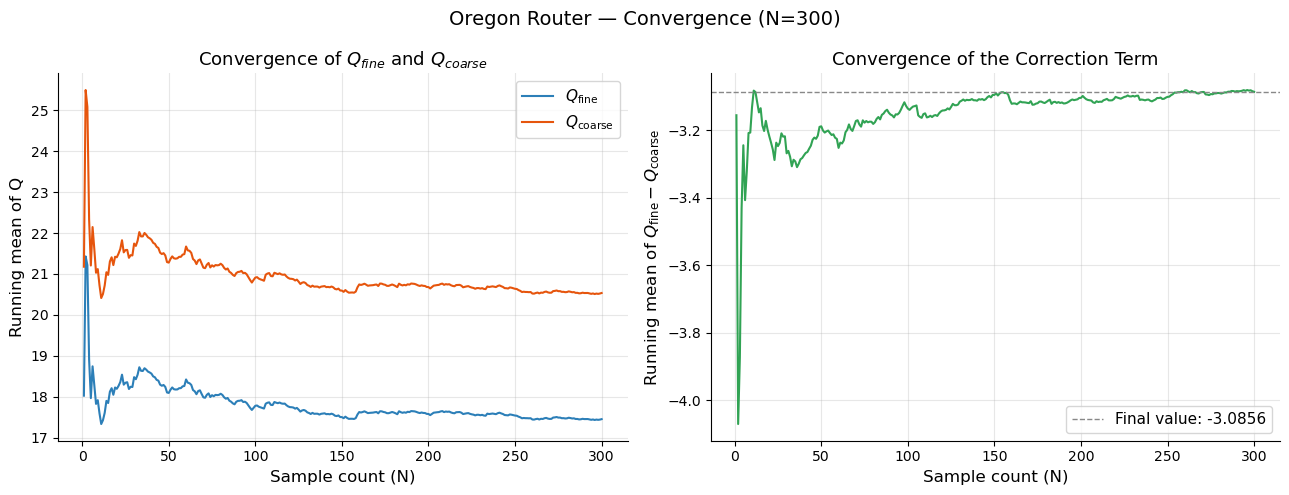

saved oregon_convergence.png


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# assumes result['Q_fine_samples'], result['Q_coarse_samples'] already exist
# from your Oregon Router run_paired_validation(setup, N=300) call

result = run_paired_validation(setup, N=300)

Q_fine_samples = result['Q_fine_samples']
Q_coarse_samples = result['Q_coarse_samples']
diff_samples = Q_fine_samples - Q_coarse_samples

N = len(Q_fine_samples)

running_mean_fine = np.cumsum(Q_fine_samples) / np.arange(1, N + 1)
running_mean_coarse = np.cumsum(Q_coarse_samples) / np.arange(1, N + 1)
running_mean_diff = np.cumsum(diff_samples) / np.arange(1, N + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# --- Left: Q_fine and Q_coarse running means ---
ax = axes[0]
ax.plot(range(1, N + 1), running_mean_fine, label=r'$Q_{\mathrm{fine}}$', color='#2c7fb8', linewidth=1.5)
ax.plot(range(1, N + 1), running_mean_coarse, label=r'$Q_{\mathrm{coarse}}$', color='#e6550d', linewidth=1.5)
ax.set_xlabel('Sample count (N)', fontsize=12)
ax.set_ylabel('Running mean of Q', fontsize=12)
ax.set_title('Convergence of $Q_{fine}$ and $Q_{coarse}$', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# --- Right: correction term (Q_fine - Q_coarse) running mean ---
ax = axes[1]
ax.plot(range(1, N + 1), running_mean_diff, color='#31a354', linewidth=1.5)
ax.axhline(running_mean_diff[-1], color='#888', linestyle='--', linewidth=1,
           label=f'Final value: {running_mean_diff[-1]:.4f}')
ax.set_xlabel('Sample count (N)', fontsize=12)
ax.set_ylabel(r'Running mean of $Q_{\mathrm{fine}} - Q_{\mathrm{coarse}}$', fontsize=12)
ax.set_title('Convergence of the Correction Term', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Oregon Router — Convergence (N=300)', fontsize=14)
plt.tight_layout()
plt.savefig('oregon_convergence.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("saved oregon_convergence.png")

Monte Carlo: 100%|██████████| 1000/1000 [06:19<00:00,  2.64sample/s, mean Q=17.6143]



✓ Done — 1000 samples
  Mean Q : 17.614349
  Std Q  : 3.509175
Samples : 1000
Mean Q  : 17.614349
Std Q   : 3.509175


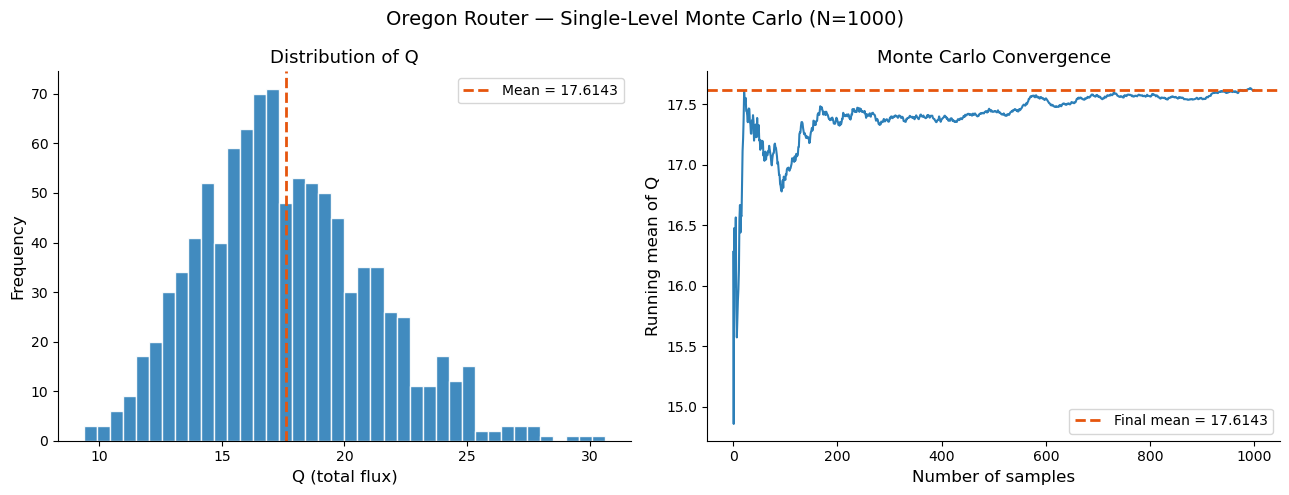

saved oregon_single_level_qoi.png


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# assumes Q_samples already exists from your single-level Oregon run:
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                                  gamma_in, gamma_out, N=1000, debug=False)

print(f"Samples : {len(Q_samples)}")
print(f"Mean Q  : {Q_samples.mean():.6f}")
print(f"Std Q   : {Q_samples.std():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# --- Histogram ---
ax = axes[0]
ax.hist(Q_samples, bins=40, color='#2c7fb8', edgecolor='white', alpha=0.9)
ax.axvline(Q_samples.mean(), color='#e6550d', linestyle='--', linewidth=2,
           label=f'Mean = {Q_samples.mean():.4f}')
ax.set_xlabel('Q (total flux)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Q', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# --- Convergence ---
ax = axes[1]
running_mean = np.cumsum(Q_samples) / np.arange(1, len(Q_samples) + 1)
ax.plot(running_mean, color='#2c7fb8', linewidth=1.5)
ax.axhline(Q_samples.mean(), color='#e6550d', linestyle='--', linewidth=2,
           label=f'Final mean = {Q_samples.mean():.4f}')
ax.set_xlabel('Number of samples', fontsize=12)
ax.set_ylabel('Running mean of Q', fontsize=12)
ax.set_title('Monte Carlo Convergence', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Oregon Router — Single-Level Monte Carlo (N=1000)', fontsize=14)
plt.tight_layout()
plt.savefig('oregon_single_level_qoi.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("saved oregon_single_level_qoi.png")